In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
# Preset values

years = [2025, 2026]
strt_month = 6

res_prop = "Residential"
res_sub = "SingleFamilyResidence"

crit_cols = ["ClosePrice", "BedroomsTotal", "BathroomsTotalInteger",
             "LivingArea", "LotSizeSquareFeet", "DaysOnMarket"]        # Define list of critical columns

new_cols = ["PostalCode", "YearBuilt", "ParkingTotal"]

sub_cols = crit_cols + new_cols

list_vals = ['OriginalListPrice', 'ListingKey', 'ListPrice', 'ListingId', 'ListingContractDate']

In [ ]:
def load_data(yrs=years, strt=strt_month):
  """
  Takes an inputted list of years and integer-valued start month for the CRMLS files
  Returns merged DataFrame of read csvs
  """
  main_df = pd.DataFrame()                                              # Defines blank DataFrame
  months = [str(i) if i > 9 else "0"+str(i) for i in range (1,13)]      # Defines proper format and type of month values

  for a in range(strt-1, 12):           # Iterates through months, starting with inputted strt month
    try:
      df = pd.read_csv("CRMLSSold"+str(yrs[0])+months[a]+".csv", low_memory=False, on_bad_lines="skip")    # Reads csv
      main_df = pd.concat([main_df, df], ignore_index=True)                           # Appends DataFrame of csv to "main_df"
    except FileNotFoundError:
      df = pd.read_csv("CRMLSSold"+str(yrs[0])+months[a]+"_filled.csv", low_memory=False)
      main_df = pd.concat([main_df, df], ignore_index=True)

  if len(yrs) > 2:                    # If "yrs" list is greater than two,
    for b in range(1,len(yrs)-1):       # For each year in "yrs", except the first and last
      for c in months:                    # Iterates through each month in "months" (whole year for yrs[b])
        try:
          df = pd.read_csv("CRMLSSold"+str(yrs[b])+c+".csv", low_memory=False)        # Reads csv
          main_df = pd.concat([main_df, df], ignore_index=True)                       # Appends DataFrame of csv to "main_df"
        except FileNotFoundError:
          df = pd.read_csv("CRMLSSold"+str(yrs[b])+c+"_filled.csv", low_memory=False)
          main_df = pd.concat([main_df, df], ignore_index=True)

  elif len(yrs) == 2:           # Elif,
    for d in range(0, strt):      # Iterates through months upto the strt for the last year in "yrs"
      try:
        df = pd.read_csv("CRMLSSold"+str(yrs[len(yrs)-1])+months[d]+".csv", low_memory=False, on_bad_lines="skip")   # Reads csv
        main_df = pd.concat([main_df, df], ignore_index=True)                                   # Appends DataFrame of csv to "main_df"
      except FileNotFoundError:
        df = pd.read_csv("CRMLSSold"+str(yrs[len(yrs)-1])+months[d]+"_filled.csv", low_memory=False)
        main_df = pd.concat([main_df, df], ignore_index=True)

  return main_df

# **Preprocessing Analysis**

Essential Non-null Columns (Quantitatively):
* "ClosePrice", "BedroomsTotal", "BathroomsTotalInteger", "LivingArea", "LotSizeSquareFeet", "DaysOnMarket"

Important Qualitative Features:
* "CloseDate", "UnparsedAddress", "ListingKey"

Non-Zero Values:
* "ClosePrice", "BedroomsTotal", "BathroomsTotalInteger", "LivingArea", "LotSizeSquareFeet", "DaysOnMarket", *"Latitude", "Longitude"*

Pre-set Values & Validation:
* "PropertyType" = "Residential"
* "PropertySubType" == "SingleFamilyResidence"
* "StateOrProvince" == "CA"
* *Note: Null or zero-valued "Longitude" and "Latitude values will not need to be dropped as long as "StateorProvince == CA*
* *Note: MlsStatus == "Closed" is implied for non-null "CloseDate" values*

Comparisons:
* "PostalCode", "City", "CountyOrParish"
* "ParkingTotal", "GarageSpaces"
* "Stories", "Levels"

Additional Features:
* "YearBuilt", "ViewYN", "FireplaceYN", "NewConstructionYN"
* *Note: 'YearBuilt' only fills in the gaps for 'NewConstructionYN' if a house has been built from scratch. Thus, it does not account for any type of additions or improvements constructed.*

In [ ]:
main_df = load_data()

In [ ]:
print(main_df[["LotSizeSquareFeet", "LivingArea", "BedroomsTotal", "BathroomsTotalInteger",
              "ClosePrice", "DaysOnMarket"]].isnull().sum())
print("\t\t All null values from these columns will need to be dropped.")
print("\n")

print(main_df[["ListingKey", "CloseDate"]].isnull().sum())
print("\t\t It is important that 'CloseDate' has all non-null values (MlsStatus is Closed).")
print(main_df[["UnparsedAddress", "Latitude", "Longitude", "StateOrProvince"]].isnull().sum())
print("\t\t These columns do not need to have rows dropped.")
print("\n")

print(main_df[["City", "PostalCode", "CountyOrParish"]].isnull().sum())
print(f"Unique Values: \t City={len(pd.unique(main_df["City"]))}, PostalCode={len(pd.unique(main_df["PostalCode"]))}, CountyOrParish={len(pd.unique(main_df["CountyOrParish"]))}")
print("\t\t It would be beneficial to experiment with which of these values would be best used to distinguish regional prices in the dataset.")
print("\t\t I intend to use 'PostalCode' as it will likely be the best indicator of ranges in property price.")
print(main_df[["ParkingTotal", "GarageSpaces"]].isnull().sum())
print("\t\t 'ParkingTotal' has much fewer null values than 'GarageSpaces', making it the ideal choice of the two.")
print(main_df[["Stories", "Levels"]].isnull().sum())
print("\t\t 'Stories' is the numeric version of 'Levels' making it the preferred option. However, 'Levels' has fewer, yet a somewhat significant, number of null values.")
print("\n")

print(main_df[["NewConstructionYN", "ViewYN", "FireplaceYN", "YearBuilt"]].isnull().sum())
print("\t\t These are optional, potentially useful parameters.")
print("\t\t 'YearBuilt' may reasonably have its null values dropped. Yet, the other columns should be reexamined after dropping nulls from the critical columns.")

LotSizeSquareFeet        23198
LivingArea               19296
BedroomsTotal            18011
BathroomsTotalInteger    12375
ClosePrice                   2
DaysOnMarket                 0
dtype: int64
		 All null values from these columns will need to be dropped.


ListingKey    0
CloseDate     0
dtype: int64
		 It is important that 'CloseDate' has all non-null values (MlsStatus is Closed).
UnparsedAddress    428
Latitude            55
Longitude           50
StateOrProvince      1
dtype: int64
		 These columns do not need to be dropped.


City              73
PostalCode        73
CountyOrParish     0
dtype: int64
Unique Values: 	 City=1128, PostalCode=2766, CountyOrParish=60
		 It would be beneficial to experiment with which of these values would be best used to distinguish regional prices in the dataset.
		 I intend to use 'PostalCode' as it will likely be the best indicator of ranges in property price.
ParkingTotal     7916
GarageSpaces    36348
dtype: int64
		 'ParkingTotal' has much 

In [ ]:
def clean_data(df, crit=crit_cols, prop=res_prop, sub_prop=res_sub):
  """
  Takes a DataFrame and list of critical columns
  Returns a DataFrame with duplicate values dropped, as well as null and zeros based on subsets of columns
  """
  clean_df = df[(df["PropertyType"] == prop)&(df["PropertySubType"] == sub_prop)]     # Takes subset of DataFrame based on property type and subtype
  clean_df = clean_df[clean_df["StateOrProvince"] == "CA"]                            # Takes subset of DataFrame where the only state is CA
  clean_df.drop_duplicates(inplace=True, ignore_index=True)
  clean_df.dropna(subset=crit, inplace=True, ignore_index=True)

  for col in crit:
    if "." in str(clean_df[col].loc[0]):
      clean_df[col] = clean_df[col].astype("float64")
    else:
      clean_df[col] = clean_df[col].astype("int64")

  for col in crit:                              # For each critical column
    clean_df = clean_df[clean_df[col]>0]          # Only include rows in each column col has values greater than 0
  return clean_df.reset_index(drop=True)

In [ ]:
clean_df = clean_data(main_df)

In [ ]:
print(clean_df[["LotSizeSquareFeet", "LivingArea", "BedroomsTotal", "BathroomsTotalInteger",
              "ClosePrice", "DaysOnMarket"]].isnull().sum())
print("\t\t Critical columns have been cleaned.")
print("\n")

print(clean_df[["UnparsedAddress", "Latitude", "Longitude"]].isnull().sum())
print("\t\t The nulls are reduced, and these columns still do not need to be dropped.")
print("\n")

print(clean_df[["City", "PostalCode", "CountyOrParish"]].isnull().sum())
print(f"Unique Values: \t City={len(pd.unique(clean_df["City"]))}, PostalCode={len(pd.unique(clean_df["PostalCode"]))}, CountyOrParish={len(pd.unique(clean_df["CountyOrParish"]))}")
diff = 1-((len(pd.unique(clean_df["PostalCode"])))/(len(pd.unique(main_df["PostalCode"]))))
print(f"\t\t 'PostalCode' now has only one null value, but the number of unique codes has been reduced by about {int(round(diff*100,0))}%.")
print(clean_df[["ParkingTotal", "GarageSpaces"]].isnull().sum())
park0 = len(clean_df[clean_df["ParkingTotal"] == 0.0])
print(f"\t\t 'ParkingTotal' now has only one null value and {park0} zero values.")
print(clean_df[["Stories", "Levels"]].isnull().sum())
print("\t\t The null value total in these sets is still somewhat large, given the size of the data set.")
print("\n")

print(clean_df[["NewConstructionYN", "ViewYN", "FireplaceYN", "YearBuilt"]].isnull().sum())
print("\t\t The null values of these columns have lowered significantly.")
bld = clean_df[["NewConstructionYN", "YearBuilt", "CloseDate"]].dropna(subset=["YearBuilt"])
print("Below are the null counts for a table where 'YearBuilt' has the same year as 'CloseDate':")
print(bld[bld["YearBuilt"] == [int(i[0:4]) for i in bld['CloseDate']]].isnull().sum())
print("\t\t Only one null, implies we cannot easily impute the values for NewConstructionYN when 'YearBuilt' has the same year as 'CloseDate'.")

LotSizeSquareFeet        0
LivingArea               0
BedroomsTotal            0
BathroomsTotalInteger    0
ClosePrice               0
DaysOnMarket             0
dtype: int64
		 Critical columns have been cleaned.


UnparsedAddress    96
Latitude           12
Longitude          12
dtype: int64
		 The nulls are reduced, and these columns still do not need to be dropped.


City              34
PostalCode         1
CountyOrParish     0
dtype: int64
Unique Values: 	 City=1003, PostalCode=2134, CountyOrParish=60
		 'PostalCode' now has only one null value, but the number of unique codes has been reduced by about 23%.
ParkingTotal       1
GarageSpaces    5287
dtype: int64
		 'ParkingTotal' now has only one null value and 8085 zero values.
Stories    13848
Levels      9663
dtype: int64
		 The null value total in these sets is still somewhat large, given the size of the data set.


NewConstructionYN    10312
ViewYN               12551
FireplaceYN             99
YearBuilt               66
dtype

**Close Price Inconsistency**

Upon analyzing a list of the maximum and minimum values for the critical columns of the dataset, there appear to be discrepencies. In particular, after comparing 'OriginalListPrice' with 'ClosePrice', it seems that some values of close price represent different units than the other values. For example 1.75 is listed as a close price, but, given the list value, it seems to represent 1.75 million. Thus, some rows will need to be dropped or altered to enhance the data.

In [ ]:
def re_clean(df, new=new_cols):
  """
  Takes a DataFrame and list of columns
  Returns a DataFrame with null values from the inputted columns dropped
  """
  new_df = df[df["ClosePrice"] > 22000].reset_index(drop=True)       # Addresses data entry discrepencies
  drp_close = []
  new_df["ListPrice"] = new_df["ListPrice"].astype("float64")
  for row in range(len(new_df)):
    close, lst = new_df['ClosePrice'].loc[row], new_df['ListPrice'].loc[row]
    if lst/close > 2 or close/lst > 2:
      drp_close.append(row)
  new_df = new_df.drop(drp_close)

  for col in new:
    try:
      if "." in str(new_df[col].loc[0]):
        new_df[col] = new_df[col].astype("float64")
      else:
        new_df[col] = new_df[col].astype("int64")
    except:
      None

  new_df = new_df.dropna(subset=new, ignore_index=True)
  if "ParkingTotal" in new:                             # If null values are being dropped from "ParkingTotal"
    drp = new_df[(new_df["ParkingTotal"] == 0.0)&(new_df["GarageSpaces"] != 0.0)&(
        new_df["GarageSpaces"].notna() == True)]        # Defines rows where "ParkingTotal" is 0, but non-null "GarageSpaces" values are not 0
    new_df = new_df.drop(drp.index)                     # Drops the rows from "drp"
  return new_df.reset_index(drop=True)

In [ ]:
clean = re_clean(clean_df)

Display of outliers within critical columns of DataFrame.

In [ ]:
for i in sub_cols:
  try:
    df_vals, df_copy = clean[i].to_list(), clean[i].to_list()
    while max(df_vals) == max(df_copy):
      df_copy.remove(max(df_vals))
    print(f"{i}: \t\t {min(df_vals)}, \t {max(df_copy)}, \t {max(df_vals)}")
    print(f"\t\t\t {df_vals.count(min(df_vals))}, \t {df_vals.count(max(df_copy))}, \t {df_vals.count(max(df_vals))}")
    print("\n")
  except:
    None

ClosePrice: 		 26000.0, 	 63100000.0, 	 110000000.0
			 2, 	 1, 	 1


BedroomsTotal: 		 1.0, 	 19.0, 	 22.0
			 813, 	 1, 	 1


BathroomsTotalInteger: 		 1.0, 	 27.0, 	 35.0
			 11972, 	 1, 	 1


LivingArea: 		 105.0, 	 31068.0, 	 56500.0
			 1, 	 1, 	 1


LotSizeSquareFeet: 		 0.03, 	 1802599920.0, 	 1897473600.0
			 2, 	 1, 	 3


DaysOnMarket: 		 1, 	 1553, 	 2177
			 1521, 	 1, 	 1


PostalCode: 		 06021, 	 96161, 	 96962
			 1, 	 3, 	 1


YearBuilt: 		 1801.0, 	 2026.0, 	 2027.0
			 3, 	 872, 	 1


ParkingTotal: 		 -20.0, 	 1111.0, 	 3921.0
			 1, 	 1, 	 1




In [ ]:
def cln_ouliers(df):
  drp = []
  for row in range(len(df)):
    if int(df['CloseDate'].iloc[row][0:4]) < int(df["YearBuilt"].iloc[row]):
      drp.append(row)
  new_df = df.drop(drp)
  return new_df.reset_index(drop=True)

In [ ]:
cleaner = cln_ouliers(clean)

# **Correlation Analysis**

Additional columns were analyzed for their correlation to the critical columns of the DataFrame. Thus, it could better be determined whether respectively dropping the nulls of these columns would be of benefit.

Correlation matrices were used on 6 columns:
* 'ViewYN'
* 'PoolPrivateYN'
* 'FireplaceYN'
* 'Levels'
* 'NewConstructionYN'
* 'GarageSpaces'

These columns were chosen from a list of features, as ones with a fairly reasonable amount of null values. The list of these features is:
*   ['ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN',
'FireplacesTotal', 'AssociationFeeFrequency', 'AttachedGarageYN',
'BuildingAreaTotal', 'BelowGradeFinishedArea', 'CoveredSpaces',
'FireplaceYN', 'Stories', 'Levels', 'MainLevelBedrooms',
'NewConstructionYN', 'GarageSpaces', 'AssociationFee']

Negative correlation values were addressed separately.

In [ ]:
print(cleaner[['WaterfrontYN', 'BasementYN', 'FireplacesTotal', 'AssociationFeeFrequency', 'AttachedGarageYN', 'BuildingAreaTotal',
             'BelowGradeFinishedArea', 'CoveredSpaces', 'Stories', 'MainLevelBedrooms', 'AssociationFee']].isnull().sum())
cleaner[['ViewYN', 'NewConstructionYN', 'PoolPrivateYN', 'Levels', 'GarageSpaces', 'FireplaceYN']].isnull().sum()

WaterfrontYN               134093
BasementYN                 130888
FireplacesTotal            134161
AssociationFeeFrequency    100003
AttachedGarageYN            15461
BuildingAreaTotal          125275
BelowGradeFinishedArea     133172
CoveredSpaces              134161
Stories                     13760
MainLevelBedrooms           50760
AssociationFee              38050
dtype: int64


,0
ViewYN,12543
NewConstructionYN,10280
PoolPrivateYN,10296
Levels,9598
GarageSpaces,5250
FireplaceYN,96


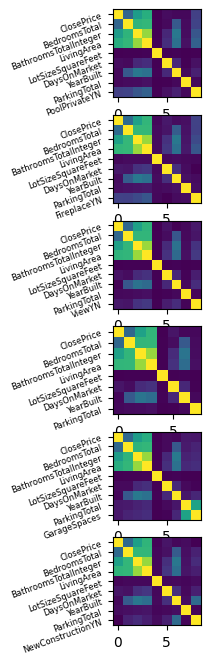

In [ ]:
fig, ax = plt.subplots(6,1, figsize=(10,8))

pool = clean.dropna(subset=["PoolPrivateYN"])
pool = pool.astype({'PoolPrivateYN': "int32"})
mat1 = pool[(sub_cols+["PoolPrivateYN"])].corr(numeric_only=True)       # Computes correlation matrix
ax[0].imshow(mat1)                                # Plots visualization of correlation matrix
lbls1 = [col for col in mat1]                                                  # Defines list of column titles as "lbls"
ax[0].set_yticks(range(len(lbls1)), labels=lbls1, rotation=20, fontsize=6)                                    # Labels y-ticks

fire = clean.dropna(subset=["FireplaceYN"])
fire = fire.astype({'FireplaceYN': "int32"})
mat2 = fire[(sub_cols+["FireplaceYN"])].corr(numeric_only=True)       # Computes correlation matrix
ax[1].imshow(mat2)                                # Plots visualization of correlation matrix
lbls2 = [col for col in mat2]                                                  # Defines list of column titles as "lbls"
ax[1].set_yticks(range(len(lbls2)), labels=lbls2, rotation=20, fontsize=6)                                    # Labels y-ticks

view = clean.dropna(subset=["ViewYN"])
view = view.astype({'ViewYN': "int32"})
mat3 = view[(sub_cols+["ViewYN"])].corr(numeric_only=True)       # Computes correlation matrix
ax[2].imshow(mat3)                                # Plots visualization of correlation matrix
lbls3 = [col for col in mat3]                                                  # Defines list of column titles as "lbls"
ax[2].set_yticks(range(len(lbls3)), labels=lbls3, rotation=20, fontsize=6)                                    # Labels y-ticks

con = clean.dropna(subset=["NewConstructionYN"])
con = con.astype({'NewConstructionYN': "int32"})
mat6 = con[(sub_cols+["NewConstructionYN"])].corr(numeric_only=True)       # Computes correlation matrix
ax[5].imshow(mat6)                                # Plots visualization of correlation matrix
lbls6 = [col for col in mat6]                                                  # Defines list of column titles as "lbls"
ax[5].set_yticks(range(len(lbls6)), labels=lbls6, rotation=20, fontsize=6)                                    # Labels y-ticks

levs = clean.dropna(subset=["Levels"])
mat4 = levs[(sub_cols+["Levels"])].corr(numeric_only=True)       # Computes correlation matrix
ax[3].imshow(mat4)                                # Plots visualization of correlation matrix
lbls4 = [col for col in mat4]                                                  # Defines list of column titles as "lbls"
ax[3].set_yticks(range(len(lbls4)), labels=lbls4, rotation=20, fontsize=6)                                    # Labels y-ticks

gar = clean.dropna(subset=["GarageSpaces"])
mat5 = gar[(sub_cols+["GarageSpaces"])].corr(numeric_only=True)       # Computes correlation matrix
ax[4].imshow(mat5)                                # Plots visualization of correlation matrix
lbls5 = [col for col in mat5]                                                  # Defines list of column titles as "lbls"
ax[4].set_yticks(range(len(lbls5)), labels=lbls5, rotation=20, fontsize=6)                                    # Labels y-ticks

plt.show()

In [ ]:
def encode_df(df, add_col=True):
  """
  Takes the DataFrame, PropertyType value (str), PropertySubType value (str), and list of columns for subset DataFrame
  Returns subset of inputted DataFrame, based on inputted parameters
  """
  drop_cols = ['WaterfrontYN', 'BasementYN', 'FireplacesTotal', 'AssociationFeeFrequency', 'AttachedGarageYN',
    'BuildingAreaTotal', 'BelowGradeFinishedArea', 'CoveredSpaces', 'Stories', 'MainLevelBedrooms',
    'AssociationFee'] + [i for i in df.columns if "Buyer" in i or "List" in i and i not in list_vals]

  sub_df = df.copy().drop(columns=drop_cols)
  sub_df["CloseDate"] = pd.to_datetime(sub_df["CloseDate"])     # Converts "CloseDate" values to datetime type
  zips = [int(str(a)[0:5]) for a in sub_df['PostalCode'].to_list()]    # Converts "PostalCode" values to int type
  sub_df['PostalCode'] = pd.DataFrame({"PostalCode": zips})        # Replaces "PostalCode" values with int type

  for col in sub_df:
    if "YN" in col:
      sub_df = pd.get_dummies(sub_df, columns=[col], dtype=int)

  if add_col==True:
    mos = [sub_df["CloseDate"][i].month for i in range(len(sub_df))]      # Defines a list of months from "CloseDate"
    sub_df.insert(sub_df.shape[1], "SaleMonth", mos)                       # Inserts a new column of sales months into the df

  return sub_df

In [ ]:
def save_csv(df, filename):
  """
  Takes a DataFrame
  Saves the inputted DataFrame as a .csv file, given inputted name
  """
  df.to_csv(filename, index=False)

In [ ]:
def test_train_split(df):
  """
  Takes a DataFrame
  Encodes "PropertyType" column
  Returns a defined training and test set for the DataFrame
  """
  yr_mo = []
  yr, mo = years[len(years)-1], strt_month
  for i in df['CloseDate']:                                         # For each date in the "CloseDate" column
    yr, mo = i.year, i.month                                          # Define the year and month values of date i
    yr_mo.append([yr,mo])                                             # Append to "yr_mo" a list of date i's year and month
  te_set = [b for b in range(len(yr_mo)) if yr_mo[b] == [yr,mo]]   # Define a list of row #s with date 05/2026
  te_rng = te_set[0::len(te_set)-1]                                 # Define a list of the first and last row in "te_set"
  tr, te = df[0:te_rng[0]], df[te_rng[0]:te_rng[1]]             # Define the training and test sets of the inputted df

  return tr, te

In [ ]:
def main():
  main_df = load_data()
  clean_df = clean_data(main_df)
  clean = re_clean(clean_df)
  cleaner_df = cln_ouliers(clean)
  sub = encode_df(cleaner_df)
  save_csv(sub, "CRMLS_0625-0626_clean.csv")

  train, test = test_train_split(sub)

In [ ]:
if __name__ == "__main__":
  main()

# **The following code was used to further clean the data:**

**"Levels"**

Fills null values of "Levels", with non-null values of "Stories".

Drops remaining null values from "Levels".

Converts string values in "Levels" to integer values.

In [ ]:
# indx = (main_df[["Stories", "Levels"]][(main_df["Levels"].notna() == False) & (main_df["Stories"].notna() == True)]).index
# main_df['Levels'][indx] = main_df['Stories'][indx].astype("int64")

In [ ]:
# main_df.dropna(subset=["Levels"], inplace=True, ignore_index=True)

In [ ]:
# enc = {"One": 1, "Two": 2, "ThreeOrMore": 3, "MultiSplit": 1.5}

# new = []
# for val in main_df["Levels"]:
#   try:
#     lst = val.split(",")
#     lst = pd.Series(lst)
#     nums = lst.replace(enc)
#     lvl = max(nums)
#     new.append(lvl)
#   except:
#     new.append(val)
# main_df["Levels"] = pd.DataFrame(new)

**"ClosePrice"**

Results outliers in "ClosePrice" values of dataset.

In [ ]:
# new_close = []
# for row in range(len(main_df)):
#   close, lst = main_df['ClosePrice'].iloc[row], main_df['ListPrice'].iloc[row]
#   if lst/close > 2:
#     while lst/close > 2:
#       close = close*10
#     if close/lst > 2:
#       new_close.append(0)
#     else:
#       # print(lst, close, main_df['DaysOnMarket'].iloc[row])
#       new_close.append(close)
#   else:
#     new_close.append(close)

# main_df["ClosePrice"] = pd.DataFrame(new_close)
# main_df = main_df[main_df["ClosePrice"] > 0]

**"ParkingTotal", "DaysOnMarket"**

Reduces outliers in "ParkingTotal" and "DaysOnMarket" columns.

Replaces negative "ParkingTotal" values with the absolute value of the "ParkingTotal".

In [ ]:
# for col in ["DaysOnMarket", "ParkingTotal"]:
#   drps = []
#   df_vals, df_copy = main_df[col].to_list(), main_df[col].to_list()
#   while max(df_vals) == max(df_copy):
#     df_copy.remove(max(df_vals))
#   while (max(df_vals)/max(df_copy)) >= 1.75:
#     drps.append(max(df_vals))
#     df_vals.remove(max(df_vals))
#     df_copy.remove(max(df_copy))
#   main_df = main_df[(main_df[col] < drps[len(drps)-1])]

In [ ]:
# indx = (main_df[main_df["ParkingTotal"] < 0]).index
# pos = []
# for val in main_df["ParkingTotal"][indx]:
#   pos.append(abs(val))
# main_df["ParkingTotal"].replace(to_replace=[(-1)*i for i in pos], value=pos, inplace=True)